In [1]:
import pandas as pd
import numpy as np

In [2]:
fileName = './data/bccard_201906.csv'
bc_df = pd.read_csv(fileName, index_col=0, )
bc_df.head()

,REG_YYMM,MEGA_CTY_NO,MEGA_CTY_NM,CTY_RGN_NO,CTY_RGN_NM,ADMI_CTY_NO,ADMI_CTY_NM,MAIN_BUZ_CODE,MAIN_BUZ_DESC,TP_GRP_NO,...,CSTMR_GUBUN,CSTMR_MEGA_CTY_NO,CSTMR_MEGA_CTY_NM,CSTMR_CTY_RGN_NO,CSTMR_CTY_RGN_NM,SEX_CTGO_CD,AGE_VAL,FLC,AMT,CNT
0,201906,11,서울특별시,1162,관악구,11620585,낙성대동,80,음식,80,...,내국인,11,서울특별시,1162,관악구,2,30대,2,26284804,1892
1,201906,11,서울특별시,1159,동작구,11590560,상도4동,30,생활,40,...,내국인,11,서울특별시,1165,서초구,2,20대,1,109290,18
2,201906,11,서울특별시,1162,관악구,11620595,청룡동,30,생활,83,...,내국인,11,서울특별시,1162,관악구,1,20대,1,268850,52
3,201906,11,서울특별시,1144,마포구,11440660,서교동,80,음식,80,...,내국인,11,서울특별시,1138,은평구,1,20대,1,44174450,1790
4,201906,11,서울특별시,1120,성동구,11200550,사근동,80,음식,80,...,내국인,11,서울특별시,1120,성동구,1,20대,1,60338146,3536


In [3]:
bc_df.tail()

,REG_YYMM,MEGA_CTY_NO,MEGA_CTY_NM,CTY_RGN_NO,CTY_RGN_NM,ADMI_CTY_NO,ADMI_CTY_NM,MAIN_BUZ_CODE,MAIN_BUZ_DESC,TP_GRP_NO,...,CSTMR_GUBUN,CSTMR_MEGA_CTY_NO,CSTMR_MEGA_CTY_NM,CSTMR_CTY_RGN_NO,CSTMR_CTY_RGN_NM,SEX_CTGO_CD,AGE_VAL,FLC,AMT,CNT
99996,201906,11,서울특별시,1165,서초구,11650520,서초2동,30,생활,40,...,내국인,43,충청북도,4311,청주시,1,50대,4,50600,10
99997,201906,11,서울특별시,1117,용산구,11170520,용산2가동,30,생활,40,...,내국인,11,서울특별시,1162,관악구,1,40대,2,38640,7
99998,201906,11,서울특별시,1156,영등포구,11560535,영등포동,30,생활,40,...,내국인,28,인천광역시,2817,미추홀구,2,30대,2,340590,15
99999,201906,11,서울특별시,1141,서대문구,11410585,신촌동,40,쇼핑,42,...,내국인,44,충청남도,4413,천안시,1,20대,2,117100,3
100000,201906,11,서울특별시,1135,노원구,11350710,상계9동,20,문화,51,...,내국인,41,경기도,4115,의정부시,1,40대,3,5227500,7


In [4]:
print(f"데이터의 개수 : {bc_df.shape[0]}")

데이터의 개수 : 100001


In [5]:
inSeoul_dict = {'거주/비거주':['서울시 거주', '서울시 비거주']}
inSeoul_df = pd.DataFrame(index = ['서울시 거주', '서울시 비거주'])
inSeoul_df

""
서울시 거주
서울시 비거주


In [6]:
ins_df = bc_df[bc_df['CSTMR_MEGA_CTY_NM'] == '서울특별시']
des_df = bc_df[bc_df['CSTMR_MEGA_CTY_NM'] != '서울특별시']

inSeoul_df['고객 수'] = [len(ins_df), len(des_df)]
inSeoul_df['총 소비액'] = [sum(ins_df['AMT'].values), sum(des_df['AMT'].values)]
inSeoul_df['카드 이용 건수'] = [sum(ins_df['CNT'].values), sum(des_df['CNT'].values)]

inSeoul_df

,고객 수,총 소비액,카드 이용 건수
서울시 거주,54150,119663142676,5542462
서울시 비거주,45851,146587135822,4950200


In [7]:
plex_dict = {'카드':['소비액']}
plex_df = pd.DataFrame(index = ['소비액'])
plex_df

""
소비액


In [8]:
se_df = bc_df[bc_df['TP_BUZ_NM'] == '편 의 점']
gn_df = bc_df[bc_df['MEGA_CTY_NM'] == '서울특별시']
gnse_df = bc_df[(bc_df['CTY_RGN_NM'] == '강남구') & (bc_df['TP_BUZ_NM'] == '편 의 점')]

plex_df['편의점 소비액'] = [sum(se_df['AMT'].values)]
plex_df['서울시 소비액'] = [sum(gn_df['AMT'].values)]
plex_df['강남구 편의점 소비액'] = [sum(gnse_df['AMT'].values)]

plex_df

,편의점 소비액,서울시 소비액,강남구 편의점 소비액
소비액,7299184098,266250278498,707275140


In [9]:
gnplex_dict = {'갱냄스퉤일' : ['거주자', '비거주자']}
gnplex_df = pd.DataFrame(index = ['거주자', '비거주자'])
gnplex_df

""
거주자
비거주자


In [10]:
gnEasymart_df = bc_df[(bc_df['CTY_RGN_NM'] == '강남구') & (bc_df['TP_BUZ_NM'] == '편 의 점')]
gnPeople = gnEasymart_df[gnEasymart_df['CSTMR_CTY_RGN_NM'] == '강남구']
notGnPeople = gnEasymart_df[gnEasymart_df['CSTMR_CTY_RGN_NM'] != '강남구']

gnplex_df['편의점 소비액'] = [sum(gnPeople['AMT']), sum(notGnPeople['AMT'])]
gnplex_df


,편의점 소비액
거주자,288379890
비거주자,418895250


<Axes: >

c:\Users\user\anaconda3\envs\textmine26\lib\site-packages\IPython\core\events.py:93: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\user\anaconda3\envs\textmine26\lib\site-packages\IPython\core\events.py:93: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\user\anaconda3\envs\textmine26\lib\site-packages\IPython\core\events.py:93: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\user\anaconda3\envs\textmine26\lib\site-packages\IPython\core\events.py:93: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\user\anaconda3\envs\textmine26\lib\site-packages\IPython\core\events.py:93: UserWarning: Glyph 54200 (\N{HANGUL SYLLABLE PYEON}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\user\anaconda3\envs\te

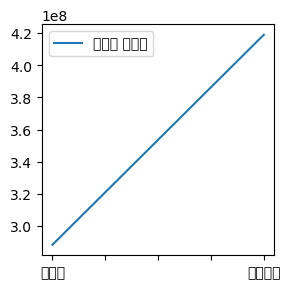

In [11]:
gnplex_df.plot(figsize=(3, 3))